In [ ]:
# Only run once

import sys
!{sys.executable} -m pip install -e /Users/andrealabudzki/Library/CloudStorage/OneDrive-AMOLF/Documents/Repositories/LOCOMYCO

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imwrite, TiffFile
from pathlib import Path
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration
from PIL import Image
from datetime import datetime
import subprocess
from pathlib import Path
import colorcet as cc
import napari
from napari.utils import Colormap
from locomyco.stack_analysis.stack_analysis import StackAnalysis
from locomyco.napari.utils.layer_helper import load_stack

In [4]:
# register colormap
# colorcet gives you a list of RGB hex strings
cbl1_colors = cc.CET_CBL1  # this is a list of hex colors

# wrap it as a napari Colormap
cbl1_cmap = Colormap(cbl1_colors, name='cet_cbl1')
#viewer.layers['your_layer'].colormap = Colormap(cc.CET_CBL1, name='cet_cbl1')

In [5]:
bool_save = False
bool_3d = False

In [6]:

# # path_movie = Path(
# #     #20 x
# # # rf'/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/5. Lipids and Organelles imaging/RawData/260408/CFL2601A049/Run01/Run01_MMStack_Pos0.ome.tif'
# #     # 60 x
# # # rf'/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/5. Lipids and Organelles imaging/RawData/260408/CFL2601A049/Run02/Run02_MMStack_Pos0.ome.tif'
# # # rf'/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/5. Lipids and Organelles imaging/RawData/260408/CFL2601A049/Run03/Run03_MMStack_Pos0.ome.tif'
# # # rf'/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/5. Lipids and Organelles imaging/RawData/250721/SAL2506A042/Mov20/Mov20_MMStack_Pos0.ome.tif'
# # # rf'/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/5. Lipids and Organelles imaging/RawData/260401/CFL2601A058/Run07/Run07_MMStack_Pos0.ome.tif'
# # # rf'/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/5. Lipids and Organelles imaging/RawData/251128/CFL2510A005/Run4/Run4_MMStack_Pos0.ome.tif'
# # rf'/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/5. Lipids and Organelles imaging/RawData/260301/CFL2601A045/Run04/Run04_MMStack_Pos0.ome.tif'
# # )

# path_movie = Path(file_path)



def choose_file():
    script = '''
    set theFile to choose file with prompt "Select movie file:"
    return POSIX path of theFile
    '''
    result = subprocess.run(["osascript", "-e", script], capture_output=True, text=True)
    return result.stdout.strip()

path_movie = Path(choose_file())
print(path_movie)




/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/5. Lipids and Organelles imaging/RawData/260619/CFL2605A126/Run07_130412/Stack_Run07_130412/Stack_Run07_130412_MMStack_Pos0.ome.tif


In [ ]:
# Loading the correct axes/dimensions from the ome tif file

# astro = load_stack_from_tif(path_movie, squeeze=False, lazy=False)
# print(astro.shape)

# with TiffFile(path_movie) as tif:
#     astro = tif.asarray()
# print(astro.shape)

# with TiffFile(path_movie) as tif:
#     series = tif.series[0]
#     print("axes:", series.axes)
#     print("shape:", series.shape)

sa = StackAnalysis(path_tif=path_movie)
stack = sa.load_raw_stack(lazy=False)
astro = stack.squeeze()
print(astro.shape)

# get scale 
eff_px = sa.eff_px_size
z_step = sa.piezo_step or 1.0

scale_3d = (z_step, eff_px, eff_px)   # for (Z, Y, X) volumes
scale_2d = (eff_px, eff_px)           # for a single (Y, X) plane

(30, 17, 592, 2028)


In [ ]:
# Add the original volume to napari

viewer = napari.Viewer()
load_stack(viewer, sa, raw_stack=True) #to use the correct z scale
layer = viewer.layers['Raw video']
# layer.name = 'my_custom_name'
layer.colormap = cbl1_cmap
# viewer.add_image(astro, name='Original Volume', colormap=cbl1_cmap)

In [ ]:
z_int_data = 1 #um
# Select a specific time point from the 3D stack 
slice_index_t = 8 # first time point
slice_index_z = 8

if bool_3d:
    astro_sliced = astro[slice_index_t, :, :, :]
else:
    astro_sliced = astro[slice_index_t, slice_index_z, :, :]
    # astro = astro[slice_index_t, slice_index_z, :, :]


print(astro_sliced.shape, astro_sliced.dtype, astro_sliced.min(), astro_sliced.max())

# Subtract background before normalizing
astro_sliced = astro_sliced - astro_sliced.min()  # or use a proper background ROI if you have one

# Normalize
astro_sliced_normalized = astro_sliced / astro_sliced.max()

IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed

In [ ]:
# Add the sliced image to napari
viewer.add_image(astro_sliced, name='Sliced Image', colormap=cbl1_cmap)
viewer.add_image(astro_sliced_normalized, name='Sliced Image Normalized', colormap=cbl1_cmap)

In [ ]:
# Loading the PSF

#20x PSF
# psf = np.load('/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/x. SetUp Charac/Point spread function/20x_objective/PSF_crops/PSF_output_20260410_1045/avg_psf.npy')

#60x PSF
psf_2d = np.load('/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/x. SetUp Charac/Point spread function/2d/60x_objective/PSF_output_lateral_20260611_1230/avg_psf.npy')
psf_3d = np.load('/Users/andrealabudzki/Library/CloudStorage/Dropbox-AMOLF-SHIMIZU/DATA/Ach_data/x. SetUp Charac/PSF/Nikon_CFI_PlanApo_VC_60X_WI/psf_3d.npy')

if bool_3d:
    psf = psf_3d    
else:
    psf = psf_2d
# Normalize so it sums to 1 (required for RL deconvolution)
psf_normalized = psf / psf.sum()

print("image slice shape:", stack_single_timeframe.shape)  # should be (712, 1008)
print("PSF shape:", psf_normalized.shape)            # should also be 2D

image slice shape: (2048, 2048)
PSF shape: (31, 31)


In [ ]:
# deconvolve
deconvolved_10 = restoration.richardson_lucy(astro, psf, num_iter=10)
# deconvolved_20 = restoration.richardson_lucy(stack_single_timeframe, psf, num_iter=20)
# deconvolved_30 = restoration.richardson_lucy(stack_single_timeframe, psf, num_iter=30)

In [ ]:
# Add deconvolved image to napari
viewer.add_image(deconvolved_10, name='Deconvolved Image - 10 Iterations', colormap=cbl1_cmap)
# viewer.add_image(deconvolved_20, name='Deconvolved Image - 20 Iterations', colormap=cbl1_cmap)
# viewer.add_image(deconvolved_30, name='Deconvolved Image - 30 Iterations', colormap=cbl1_cmap)

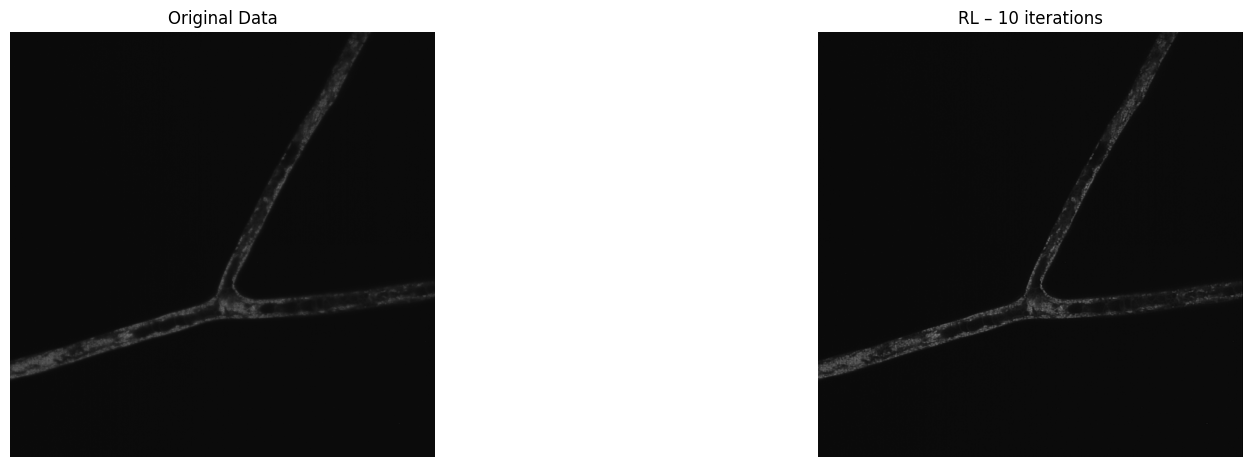

In [ ]:


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
plt.gray()

for a in ax:
    a.axis('off')

ax[0].imshow(stack_single_timeframe)
ax[0].set_title('Original Data')

ax[1].imshow(deconvolved_10, vmin=astro.min(), vmax=astro.max())
ax[1].set_title('RL – 10 iterations')

# ax[2].imshow(deconvolved_20, vmin=astro.min(), vmax=astro.max())
# ax[2].set_title('RL – 20 iterations')

# ax[3].imshow(deconvolved_30, vmin=astro.min(), vmax=astro.max())
# ax[3].set_title('RL – 30 iterations')

fig.subplots_adjust(wspace=0.02, hspace=0.2, top=0.9, bottom=0.05, left=0, right=1)
plt.show()